# Gradient Accuracy for Adaptive ODE Solvers


In [1]:
import os
import sys

parent_dir = os.path.abspath("../content")
sys.path.append(parent_dir)
os.environ["EQX_ON_ERROR"] = "nan"
from enum import Enum
from functools import partial
from typing import NamedTuple

import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt
import numpy as np
from diffrax import (
    ConstantStepSize,
    ODETerm,
    RecursiveCheckpointAdjoint,
    Tsit5,
    diffeqsolve,
)
from fastpm.core import Cosmology as FastPMCosmology
from fastpm.core import Solver, leapfrog
from jaxpm.painting import cic_paint_dx
from jaxpm.pm import linear_field, lpt
from pmesh.pm import ParticleMesh
from tools.finite_difference import numerical_jvp
from tools.integrate import integrate
from tools.ode import symplectic_ode
from tools.semi_implicite_euler import SemiImplicitEuler
from tqdm import tqdm

jax.config.update("jax_enable_x64", True)

## Initialisation

### Generate Initial Conditions

This section initializes the simulation by defining the mesh resolution, box size, and cosmological parameters.  
We generate a uniform particle grid and use the linear matter power spectrum to compute initial density fluctuations.  
A white noise field is created and filtered to match the expected power spectrum, yielding the starting conditions for the simulation.


In [2]:
mesh_shape = [64, 64, 64]
box_size = [512.0, 512.0, 512.0]

omega_c = 0.25
sigma8 = 0.8
cosmo = jc.Planck15(Omega_c=omega_c, sigma8=sigma8)

# Generate initial particle positions
pm = ParticleMesh(BoxSize=box_size, Nmesh=mesh_shape, dtype="f8")
grid = pm.generate_uniform_particle_grid(shift=0).astype(np.float64)
# Interpolate with linear_matter spectrum to get initial density field
k = jnp.logspace(-4, 1, 128)
pk = jc.power.linear_matter_power(cosmo, k)

whitec = pm.generate_whitenoise(42, type="complex", unitary=False)


def pk_fn(x):
    return jnp.interp(x.reshape([-1]), k, pk).reshape(x.shape)


lineark = whitec.apply(
    lambda k, v: pk_fn(sum(ki**2 for ki in k) ** 0.5) ** 0.5 * v * (1 / v.BoxSize).prod() ** 0.5
)
init_mesh = lineark.c2r().value
ref_cosmo = FastPMCosmology(cosmo)
solver = Solver(pm, ref_cosmo, B=1)


initial_conditions = jnp.asarray(init_mesh)

### Gradient Computation for Symplectic Solvers

This section defines the gradient computation approach for symplectic solvers such as SemiImplicitEuler and FastPM LeapFrog.  

- **LPT Initialization**: The `run_lpt` function initializes particle displacements using first-order Lagrangian Perturbation Theory (LPT).  
- **N-body Evolution**: The `run_nbody` function advances the system using a symplectic solver. It supports different adjoint methods for computing gradients:  
  - **Checkpoint Adjoint**: Uses recursive checkpointing to balance memory and computational cost.  
  - **Reverse Adjoint**: Uses reverse-mode differentiation to propagate gradients efficiently.  


In [3]:
class GradientType(Enum):
    Checkpoint = "Checkpoint"
    Reverse = "Reverse"


CHECKPOINT = GradientType.Checkpoint
REVERSE = GradientType.Reverse


class Params(NamedTuple):
    Omega_c: float
    sigma8: float


@jax.jit
def run_lpt(params, ic):
    cosmo = jc.Planck15(Omega_c=params.Omega_c, sigma8=params.sigma8)
    dx, p, _ = lpt(cosmo, ic, a=0.1, order=1)
    return dx, p


@partial(jax.jit, static_argnums=(2, 3, 4, 5, 6, 7))
def run_nbody(
    params,
    ic,
    terms,
    step_size=0.01,
    stepsize_controller=ConstantStepSize(),
    solver=Tsit5(),
    adjoint=CHECKPOINT,
    checkpoints=100,
):
    dx, p = run_lpt(params, ic)
    cosmo = jc.Planck15(Omega_c=params.Omega_c, sigma8=params.sigma8)
    y0 = (dx, p)
    if len(terms) == 3:
        *terms, first_kick_term = terms
        y0 = solver.first_step(first_kick_term, t0=0.1, dt0=step_size, y0=y0, args=(cosmo,))
        terms = tuple(terms)

    # Evolve the simulation forward
    if adjoint == CHECKPOINT:
        ode_solutions = diffeqsolve(
            terms,
            solver=solver,
            t0=0.1,
            t1=1.0,
            dt0=step_size,
            y0=y0,
            args=(cosmo,),
            stepsize_controller=stepsize_controller,
            adjoint=RecursiveCheckpointAdjoint(checkpoints=checkpoints),
        )
        last_y = jax.tree.map(lambda x: x[-1], ode_solutions.ys)
        num_steps = ode_solutions.stats["num_steps"]
        return last_y[0], num_steps

    elif adjoint == REVERSE:
        t0, t1 = 0.1, 1.0
        ode_solutions = integrate(
            terms, solver=solver, t0=t0, t1=t1, dt0=step_size, y0=y0, args=(cosmo,)
        )
        last_y = jax.tree.map(lambda x: x[-1], ode_solutions)
        return last_y[0], (t1 - t0) / step_size

    else:
        raise ValueError(f"Unknown adjoint method {adjoint}")

    return ode_solutions

### Forward Model for MSE Computation

We define a forward model that computes the Mean Squared Error (MSE) between the observed field and the generated field, which is derived from initial conditions and cosmological parameters.  

- **lpt_model**: Uses Lagrangian Perturbation Theory (LPT) to generate an approximate field and compare it with observations.  
- **model**: Runs a full N-body simulation to evolve the system and computes the MSE against the observed field.  
- **Gradient Computation**: The model is JIT-compiled for efficiency, allowing differentiation with respect to both cosmological parameters and initial conditions.  


In [4]:
def MSE(x, y):
    return jnp.mean((x - y) ** 2)


@jax.jit
def lpt_model(params, ic, obs):
    dx, p = run_lpt(params, ic)
    return MSE(cic_paint_dx(dx), obs)


@partial(jax.jit, static_argnums=(3, 4, 5, 6, 7, 8))
def model(
    params,
    ic,
    obs,
    term,
    step_size=0.01,
    stepsize_controller=ConstantStepSize(),
    solver=Tsit5(),
    adjoint=CHECKPOINT,
    checkpoints=100,
):
    y_hat, num_steps = run_nbody(
        params, ic, term, step_size, stepsize_controller, solver, adjoint, checkpoints
    )
    y_hat = y_hat
    y_hat_field = cic_paint_dx(y_hat)

    return MSE(y_hat_field, obs), num_steps


nbody = jax.jit(model, static_argnums=(3, 4, 5, 6, 7, 8))

nbody_cosmo = jax.jit(jax.grad(model, has_aux=True), static_argnums=(3, 4, 5, 6, 7, 8))
nbody_ic = jax.jit(jax.grad(model, argnums=1, has_aux=True), static_argnums=(3, 4, 5, 6, 7, 8))

#### Visualization

We visualize the projected density fields from both LPT and N-body simulations.  

- **Left (LPT)**: The field generated using first-order Lagrangian Perturbation Theory.  
- **Right (N-body)**: The evolved field using the Semi-Implicit Euler solver.  

This comparison illustrates the differences in structure formation bet


/home/wassim/micromamba/envs/jax/lib/python3.10/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


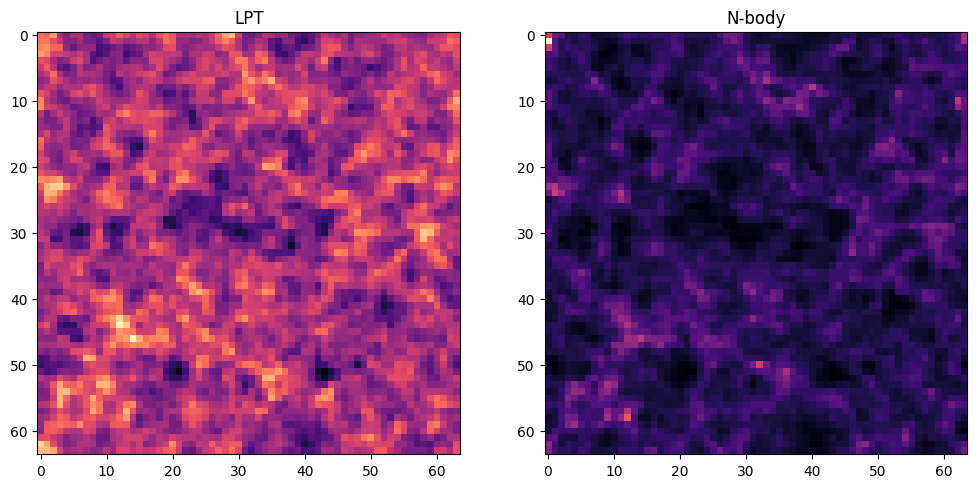

In [5]:
params = Params(0.25, 0.8)

ode_terms = jax.tree.map(lambda x: ODETerm(x), symplectic_ode(mesh_shape, paint_absolute_pos=False))
final_field, _ = run_nbody(
    params,
    initial_conditions,
    ode_terms,
    step_size=0.1,
    solver=SemiImplicitEuler(),
)
lpt_dx, _ = run_lpt(params, initial_conditions)

sie_field = cic_paint_dx(final_field)
lpt_field = cic_paint_dx(lpt_dx)

plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(lpt_field[10:].sum(axis=0), cmap="magma")
plt.title("LPT")
plt.subplot(122)
plt.imshow(sie_field[10:].sum(axis=0), cmap="magma")
plt.title("N-body")
plt.show()

### Gradient Evaluation  

We compute gradients of the N-body simulation with respect to cosmological parameters and analyze their sensitivity when moving away from the correct values.  


In [7]:
best_params = params
guess_params = Params(Omega_c=0.8, sigma8=0.8)

best_grad, _ = nbody_cosmo(
    best_params,
    initial_conditions,
    sie_field,
    ode_terms,
    step_size=0.1,
    solver=SemiImplicitEuler(),
)
guess_grad, _ = nbody_cosmo(
    guess_params,
    initial_conditions,
    sie_field,
    ode_terms,
    step_size=0.1,
    solver=SemiImplicitEuler(),
)

print(f"Gradient at the correct cosmology: {best_grad}")
print(f"Evaluating the gradient at the Correct Cosmology: {guess_grad}")

Gradient at the correct cosmology: Params(Omega_c=Array(0., dtype=float64, weak_type=True), sigma8=Array(0., dtype=float64, weak_type=True))
Evaluating the gradient at the Correct Cosmology: Params(Omega_c=Array(0.00971047, dtype=float64, weak_type=True), sigma8=Array(0., dtype=float64, weak_type=True))


#### Sensitivity to Initial Conditions  

We compute gradients of the N-body simulation with respect to initial conditions and analyze how they change when perturbing the initial field.  


In [8]:
best_ic = initial_conditions

cosmo = jc.Planck15(Omega_c=best_params.Omega_c, sigma8=best_params.sigma8)
pk = jc.power.linear_matter_power(cosmo, k)


def pk_fn_2(x):
    return jnp.interp(x.reshape([-1]), k, pk).reshape(x.shape)


# Create initial conditions
guess_ic = linear_field(mesh_shape, box_size, pk_fn_2, seed=jax.random.PRNGKey(42))


best_grad, _ = nbody_ic(
    best_params,
    best_ic,
    sie_field,
    ode_terms,
    step_size=0.1,
    solver=SemiImplicitEuler(),
)
guess_grad, _ = nbody_ic(
    best_params,
    guess_ic,
    sie_field,
    ode_terms,
    step_size=0.1,
    solver=SemiImplicitEuler(),
)

print(f"Gradient at the correct cosmology: Max {best_grad.max()} min {best_grad.min()}")
print(
    f"Evaluating the gradient at the Correct Cosmology: Max {guess_grad.max()} min {guess_grad.min()}"
)

Gradient at the correct cosmology: Max 0.0 min 0.0
Evaluating the gradient at the Correct Cosmology: Max 0.0009112757905849597 min -0.0002180826709851976


## FastPM LeapFrog in JAX  

We visualize the projected density field obtained using the FastPM LeapFrog integrator, highlighting the evolved structure from the N-body simulation.  


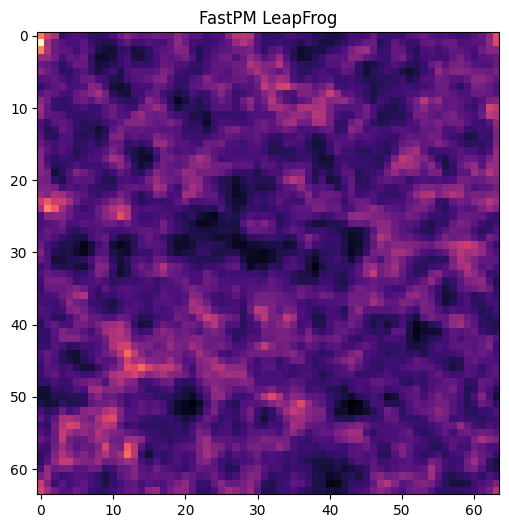

In [ ]:
from tools.ode import symplectic_fpm_ode

drift, kick, first_kick = symplectic_fpm_ode(mesh_shape, 0.1, paint_absolute_pos=False)
ode_terms = ODETerm(drift), ODETerm(kick), ODETerm(first_kick)

ode_solution_fpm, _ = run_nbody(
    params,
    initial_conditions,
    ode_terms,
    step_size=0.1,
    solver=SemiImplicitEuler(),
)
fpm_field = cic_paint_dx(ode_solution_fpm)


plt.figure(figsize=(12, 6))
plt.imshow(fpm_field[10:].sum(axis=0), cmap="magma")
plt.title("FastPM LeapFrog")


plt.show()

### Running FastPM

We execute the CPU version of FastPM to evolve the particle state using LeapFrog integration. The simulation progresses from LPT-initialized positions through multiple time steps, producing the final density field.  


In [7]:
statelpt = solver.lpt(lineark, grid, 0.1, order=1)
stages = np.linspace(0.1, 1.0, 10, endpoint=True)

leapfrog_stages = leapfrog(stages)
finalstate = solver.nbody(statelpt, leapfrog_stages)
fpm_mesh = pm.paint(finalstate.X).value

### Validating the LeapFrog Integrator  

This comparison verifies the correctness of the LeapFrog implementation by measuring its difference from FastPM. The small error between Efficient LeapFrog and FastPM confirms that the integrator is accurate, while the larger error for Semi-Implicit Euler highlights its deviation from the expected solution.  


In [ ]:
def jax_mse(x, y):
    return ((x - y) ** 2).mean()


print(
    f"Difference between FPM and EfficientLeapFrog with 10 steps is {jax_mse(fpm_field, fpm_mesh)} "
)
print(
    f"Difference between FPM and SemiImpliciteEuler with 10 steps is {jax_mse(sie_field, fpm_mesh)} "
)

Difference between FPM and EfficientLeapFrog with 10 steps is 5.773543790349877e-13 
Difference between FPM and SemiImpliciteEuler with 10 steps is 0.2754500882055956 


: 

### Validating Reverse-Mode Differentiation  

This test checks that the reverse-mode differentiation of the integrator produces exact gradients matching those obtained with checkpointing. The near-zero difference confirms the correctness of the reverse-mode gradient computation.  


In [12]:
drift, kick, first_kick = symplectic_fpm_ode(mesh_shape, 0.01, paint_absolute_pos=False)
ode_terms = ODETerm(drift), ODETerm(kick), ODETerm(first_kick)


gradients_rev, _ = nbody_ic(
    best_params,
    best_ic,
    fpm_field,
    ode_terms,
    step_size=0.01,
    solver=SemiImplicitEuler(),
    adjoint=REVERSE,
)
gradiennts_check, _ = nbody_ic(
    best_params,
    best_ic,
    fpm_field,
    ode_terms,
    step_size=0.01,
    solver=SemiImplicitEuler(),
    adjoint=CHECKPOINT,
)

print(
    f"Maximum difference between reverse and checkpoint gradients is {jnp.abs(gradients_rev - gradiennts_check).max()}"
)

Maximum difference between reverse and checkpoint gradients is 1.967334202819949e-14
